# Experiment 2B: SSC — Hidden-Layer Perturbation

## Overview

This notebook implements Experiment 2B from the "Beyond Beyond Rate" project.
We train a 2-hidden-layer SNN on the Spiking Speech Commands (SSC) dataset
with **no perturbation** (f=0), then evaluate it by applying spike-timing
perturbation to the **output of the 1st hidden layer** at test time.

### Key questions
- On SSC-norm (zero rate information in input), does the 1st hidden layer
  output still carry temporal information?
- Does SGD-delay maintain richer internal temporal representations than SGD?
- How does the hidden accuracy-vs-f curve compare to the input perturbation
  curve from the original *Beyond Rate* paper?
- Does the pattern found on SHD hold on this harder 35-class task?

### Dataset variants
| Variant | Description |
|---------|-------------|
| `whole` | Full-rate SSC: all rate and temporal information intact |
| `part`  | Partial SSC: reduced input channels, some rate info removed |
| `norm`  | Normalised SSC: rate information removed, only temporal cues remain |

### Sections
1. Imports and Setup
2. Global Configuration
3. Load SSC Dataset
4. Hidden-Layer Spike Perturbation
5. Dataset and Data Splitting
6. Network Architecture
7. Training Loop
8. Testing with Hidden-Layer Perturbation
9. Visualisation Utilities
10. Run: Train the Model (f=0)
11. Plot Training Curves
12. Hidden-Perturbation Sweep
13. Plot Results
14. Save Results
15. Model Analysis

## 1. Imports and Setup

In [1]:
import os
import json
import random

import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

import slayerSNN as snn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Global Configuration

All key hyper-parameters and switches are defined here so that switching
between dataset variants or delay/no-delay mode requires editing only
this cell.

In [ ]:
# =====================================================================
# Batch mode: when True, the main run cell trains EVERY combination of
# (dataset_key, use_delay) listed in ALL_VARIATIONS case-by-case.
# When False, only the single (DATASET_KEY, USE_DELAY) pair below is run.
# =====================================================================
TRAIN_ALL_VARIATION: bool = True

# =====================================================================
# Network variant: set to True for SGD-delay, False for SGD (no delay).
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
USE_DELAY: bool = True

# =====================================================================
# Dataset variant: "whole", "part", or "norm".
# Ignored when TRAIN_ALL_VARIATION is True.
# =====================================================================
DATASET_KEY: str = "part"

# All (dataset_key, use_delay) pairs to iterate over in batch mode.
ALL_VARIATIONS: list[tuple[str, bool]] = [
    (dataset, delay)
    for dataset in ("norm", "part", "whole")
    for delay in (False, True)
]

# --- Dataset configurations ---
# whole: 700 input neurons (full SSC)
# part / norm: 285 input neurons (sub-sampled / rate-normalised)
DATASET_CONFIGS = {
    "whole": {"h5_file": "ssc_data/ssc_whole.h5", "input_dim": 700},
    "part":  {"h5_file": "ssc_data/ssc_part.h5",  "input_dim": 285},
    "norm":  {"h5_file": "ssc_data/ssc_norm.h5",  "input_dim": 285},
}

# --- SLAYER neuron and simulation descriptors ---
# tSample=200 matches the original Beyond Rate training pipeline.
# SSC data has T=100; samples are zero-padded to T=200 on load.
SIM_PARAMS = {"Ts": 1, "tSample": 200}
LIF_PARAMS = {
    "type": "SRMALPHA",
    "theta": 10,
    "tauSr": 1,
    "tauRho": 0.1,
    "tauRef": 2,
    "scaleRef": 2,
    "scaleRho": 0.1,
}

# --- Data split ratios (applied to the combined h5 dataset) ---
TRAIN_RANGE = (0.0, 0.6)
VAL_RANGE   = (0.6, 0.75)
TEST_RANGE  = (0.75, 0.9)

# --- Training hyper-parameters ---
HIDDEN_UNITS: int        = 128
NUM_CLASSES: int         = 35   # SSC has 35 spoken-word classes
EPOCHS: int              = 600
BATCH_SIZE: int          = 128
LEARNING_RATE: float     = 0.1
SEED: int                = 42
MAX_DELAY: int           = 64
EARLY_STOP_PATIENCE: int = 300

# --- Hidden-perturbation sweep ---
F_VALUES: list   = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
NUM_REPEATS: int = 3

# --- Derived names (used only when TRAIN_ALL_VARIATION is False) ---
INPUT_DIM: int    = DATASET_CONFIGS[DATASET_KEY]["input_dim"]
H5_FILE: str      = DATASET_CONFIGS[DATASET_KEY]["h5_file"]
DELAY_TAG: str    = "delay" if USE_DELAY else "nodelay"
MODEL_PREFIX: str = f"ssc_{DATASET_KEY}_{DELAY_TAG}"

if TRAIN_ALL_VARIATION:
    print(f"Batch mode: training {len(ALL_VARIATIONS)} variations:")
    for ds, ud in ALL_VARIATIONS:
        tag = "delay" if ud else "nodelay"
        print(f"  - ssc_{ds}_{tag}")
else:
    print(f"Dataset: {DATASET_KEY} | Input dim: {INPUT_DIM}")
    print(f"Network mode: {'SGD-delay' if USE_DELAY else 'SGD (no delay)'}")
    print(f"Model prefix: {MODEL_PREFIX}")

## 3. Load SSC Dataset

Load the dense spike-train dataset from the local `.h5` file.
Each sample has shape `(num_neurons, T)` with binary spike values.
The raw SSC data has T=100 time steps; samples are zero-padded to
T=200 to match `tSample` in the SLAYER simulation parameters.

In [ ]:
def load_ssc_data(
    h5_path: str,
    target_T: int = 200,
) -> tuple[np.ndarray, np.ndarray]:
    """Load the full SSC dataset from an HDF5 file into memory.

    Mirrors ``load_shd_data`` in the SHD notebook: the whole dataset is read
    into RAM at once (the previous chunked loader is no longer needed). The
    raw SSC data has T=100 time steps; samples are zero-padded to ``target_T``
    to match ``tSample`` in the SLAYER simulation parameters.

    Args:
        h5_path: Path to the HDF5 file with keys 'X' and 'Y'.
        target_T: Target time dimension (zero-pad if shorter).

    Returns:
        Tuple (X, Y) where X has shape (N, neurons, target_T) as uint8 and
        Y has shape (N,) as int.
    """
    with h5py.File(h5_path, "r") as hf:
        X = np.array(hf["X"], dtype=np.uint8)
        Y = np.array(hf["Y"]).astype(int).ravel()

    n_samples, n_neurons, T = X.shape
    if T < target_T:
        padded = np.zeros((n_samples, n_neurons, target_T), dtype=np.uint8)
        padded[:, :, :T] = X
        X = padded
        print(f"Padded time dimension from {T} to {target_T}")

    mem = X.nbytes / (1024 ** 3)
    print(
        f"Loaded {h5_path}: X={X.shape}, Y={Y.shape}, "
        f"classes={len(np.unique(Y))} ({mem:.1f} GiB)"
    )
    return X, Y


X_all, Y_all = load_ssc_data(H5_FILE, target_T=SIM_PARAMS["tSample"])

## 4. Hidden-Layer Spike Perturbation

The core of the "Beyond Beyond Rate" approach. Given a hidden layer's binary
spike output of shape `(neurons, T)`, we randomly select a fraction `f` of
each neuron's spikes, remove them, and place the same number of spikes at
uniformly random (previously-silent) time bins. This preserves the **spike
count per neuron** while destroying **spike-timing** information in proportion
to `f`.

In [ ]:
def partial_randomize_spike_train(
    spike_train: np.ndarray,
    f: float = 0.0,
    max_attempts: int = 50,
) -> np.ndarray:
    """Randomly relocate a fraction *f* of each neuron's spikes (numpy ref).

    Kept for documentation / numpy-only callers. The training and
    evaluation paths use the vectorised GPU version ``perturb_hidden_batch``
    below, which keeps every operation on the input tensor's device.

    For every neuron, *f* of its spikes are removed from their original
    positions and placed at uniformly random empty time bins. The total
    spike count per neuron is preserved.

    Args:
        spike_train: Binary array of shape (num_neurons, T).
        f: Fraction of spikes to relocate (0 = no change, 1 = full shuffle).
        max_attempts: Max tries to find an empty time bin per spike.

    Returns:
        Perturbed spike train with the same shape and spike counts.
    """
    if f <= 0:
        return spike_train

    num_neurons, T = spike_train.shape
    new_train = np.copy(spike_train)

    for neuron_idx in range(num_neurons):
        spike_times = np.where(spike_train[neuron_idx] == 1)[0]
        for old_time in spike_times:
            if np.random.rand() < f:
                new_train[neuron_idx, old_time] = 0
                inserted = False
                attempts = 0
                while not inserted and attempts < max_attempts:
                    attempts += 1
                    new_t = np.random.randint(0, T)
                    if new_train[neuron_idx, new_t] == 0:
                        new_train[neuron_idx, new_t] = 1
                        inserted = True
    return new_train


@torch.no_grad()
def perturb_hidden_batch(
    hidden_spikes: torch.Tensor,
    f: float = 0.0,
) -> torch.Tensor:
    """Vectorised GPU-side partial spike relocation.

    For each (batch, neuron), a fraction *f* of the existing spikes are
    removed and replaced with the same number of spikes placed at randomly
    chosen previously-unoccupied time bins. Spike count per neuron is
    preserved exactly. All operations stay on the input tensor's device,
    avoiding the CPU/numpy round-trip that dominates training cost when the
    perturbation runs on every batch (mirrors the SHD/``isi_delay`` kernel;
    Section 3.6.5 of ``docs/progress/phase1to4_fixes.md``).

    Args:
        hidden_spikes: SLAYER-format tensor of shape (B, C, 1, 1, T).
        f: Fraction of spikes to relocate (0 = untouched, 1 = fully random).

    Returns:
        Perturbed tensor with the same shape, dtype, and device.
    """
    if f <= 0:
        return hidden_spikes

    B, C, H, W, T = hidden_spikes.shape
    x = hidden_spikes.view(B, C, T)
    is_spike = x > 0.5

    # Count spikes per (batch, neuron) and compute how many to move.
    n_spikes = is_spike.sum(dim=-1, keepdim=True)  # (B, C, 1)
    num_to_move = (n_spikes.float() * f).floor().long()  # (B, C, 1)

    # --- 1. Choose which existing spikes to remove ---
    # Random key per time bin; non-spike bins get +inf so they sort last.
    key = torch.rand_like(x)
    key = torch.where(is_spike, key, torch.full_like(key, 2.0))
    rank = key.argsort(dim=-1).argsort(dim=-1)
    remove_mask = rank < num_to_move  # (B, C, T)

    keep_mask = is_spike & ~remove_mask

    # --- 2. Place the same number of spikes in currently-unoccupied bins ---
    available = ~keep_mask
    key2 = torch.rand_like(x)
    key2 = torch.where(available, key2, torch.full_like(key2, 2.0))
    rank2 = key2.argsort(dim=-1).argsort(dim=-1)
    add_mask = rank2 < num_to_move  # disjoint from keep_mask by construction

    new_spikes = (keep_mask | add_mask).to(hidden_spikes.dtype)
    return new_spikes.view(B, C, H, W, T)

## 5. Dataset and Data Splitting

A `Dataset` wrapper and a helper that splits the **full in-memory** dataset
into train / validation / test `DataLoader`s, mirroring the SHD notebook (no
chunked loading). Under the train-at-f protocol the perturbation is active on
every batch during both training and evaluation via the network's
`forward(x, f)`.

In [ ]:
class SpikeDataset(Dataset):
    """In-memory dataset storing spikes as uint8, converting per-sample."""

    def __init__(self, X: np.ndarray, Y: np.ndarray):
        self.X = X  # uint8 to save memory
        self.Y = Y

    def __len__(self) -> int:
        return len(self.Y)

    def __getitem__(self, idx: int):
        x = torch.from_numpy(self.X[idx].astype(np.float32))
        y = torch.tensor(self.Y[idx], dtype=torch.long)
        return x, y


def get_split_indices(
    split_range: tuple[float, float],
    total: int,
) -> np.ndarray:
    """Return index array for a given fractional range of the dataset."""
    start = int(total * split_range[0])
    end = int(total * split_range[1])
    return np.arange(start, end)


def build_dataloaders(
    X: np.ndarray,
    Y: np.ndarray,
    batch_size: int = 128,
    seed: int = 42,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Split the full dataset and build train/val/test DataLoaders.

    Args:
        X: Full dataset features, shape (N, neurons, T).
        Y: Full dataset labels, shape (N,).
        batch_size: Batch size for all loaders.
        seed: Random seed for the train shuffle.

    Returns:
        Tuple of (train_loader, val_loader, test_loader).
    """
    N = len(Y)
    train_idx = get_split_indices(TRAIN_RANGE, N)
    val_idx = get_split_indices(VAL_RANGE, N)
    test_idx = get_split_indices(TEST_RANGE, N)

    np.random.seed(seed)
    np.random.shuffle(train_idx)

    train_ds = SpikeDataset(X[train_idx], Y[train_idx])
    val_ds = SpikeDataset(X[val_idx], Y[val_idx])
    test_ds = SpikeDataset(X[test_idx], Y[test_idx])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    return train_loader, val_loader, test_loader

## 6. Network Architecture

A 2-hidden-layer SLAYER SNN matching the original SSC architecture from the
Beyond Rate codebase, with the perturbation hook on the binary
1st-hidden-layer output (delay1 moved to the start of the 2nd layer,
Section 3.4 Option B):

```
Input -> fc1 -> spike -> hidden1 spikes -> [relocate fraction f]
      -> (delay1) -> fc2 -> spike -> (delay2) -> fc3 -> spike -> output (35)
```

`forward(x, f)` intercepts the 1st hidden layer spikes and applies the
spike-relocation perturbation (fraction `f`) through a straight-through
estimator before passing them on; `f=0.0` reproduces the unperturbed pass.

In [ ]:
class SSCNetwork(nn.Module):
    """2-hidden-layer SLAYER SNN for SSC classification.

    ``delay1`` is applied at the start of ``_second_hidden_and_output``
    (3.4 Option B) so the perturbation hook sees the 1st hidden layer's
    binary spike output directly. ``forward(x, f)`` applies the
    spike-relocation perturbation through a straight-through estimator,
    keeping the gradient path to ``fc1`` intact during training at any
    ``f > 0`` (3.2 / 7.1 of ``docs/progress/phase1to4_fixes.md``).
    """

    def __init__(
        self,
        input_dim: int,
        hidden_units: int = 128,
        num_classes: int = 35,
        use_delay: bool = True,
        max_delay: int = 64,
    ):
        super().__init__()
        slayer = snn.layer(LIF_PARAMS, SIM_PARAMS)
        self.slayer = slayer
        self.use_delay = use_delay
        self.max_delay = max_delay

        # Three FC layers with weight normalisation
        self.fc1 = nn.utils.weight_norm(
            slayer.dense(input_dim, hidden_units), name="weight"
        )
        self.fc2 = nn.utils.weight_norm(
            slayer.dense(hidden_units, hidden_units), name="weight"
        )
        self.fc3 = nn.utils.weight_norm(
            slayer.dense(hidden_units, num_classes), name="weight"
        )

        # delay1 lives at the start of _second_hidden_and_output (after the
        # perturbation hook); delay2 stays between fc2-spike and fc3.
        if use_delay:
            self.delay1 = slayer.delay(hidden_units)
            self.delay2 = slayer.delay(hidden_units)

    def _prepare_input(self, x: torch.Tensor) -> torch.Tensor:
        """Ensure input is 5-D NCHWT on the correct device."""
        if isinstance(x, np.ndarray):
            x = torch.from_numpy(x)
        if x.dim() == 3:
            x = x.unsqueeze(2).unsqueeze(3)
        return x.float().to(device)

    def _first_hidden(self, x: torch.Tensor) -> torch.Tensor:
        """Input -> PSP -> fc1 -> spike -> hidden1 spikes (strictly binary)."""
        return self.slayer.spike(self.fc1(self.slayer.psp(x)))

    def _second_hidden_and_output(self, hidden1: torch.Tensor) -> torch.Tensor:
        """hidden1 -> (delay1) -> PSP -> fc2 -> spike -> (delay2) -> PSP -> fc3 -> spike."""
        x = hidden1
        if self.use_delay:
            x = self.delay1(x)
        x = self.slayer.spike(self.fc2(self.slayer.psp(x)))
        if self.use_delay:
            x = self.delay2(x)
        x = self.slayer.spike(self.fc3(self.slayer.psp(x)))
        return x

    def _apply_perturbation(
        self,
        hidden: torch.Tensor,
        f: float,
    ) -> torch.Tensor:
        """STE wrapper around ``perturb_hidden_batch``.

        ``perturb_hidden_batch`` runs under ``@torch.no_grad()``, so the
        returned tensor is a fresh leaf with no autograd edge. Without this
        wrapper, ``loss.backward()`` cannot reach ``fc1`` and the upstream
        layer stays frozen at random init for any ``f > 0`` (Section 7.1 of
        the fixes doc). Forward value is the perturbed tensor; backward
        gradient is the identity through ``hidden``.
        """
        if f <= 0:
            return hidden
        perturbed = perturb_hidden_batch(hidden, f)
        return hidden + (perturbed - hidden).detach()

    def forward(self, x: torch.Tensor, f: float = 0.0) -> torch.Tensor:
        """Forward pass with optional hidden-layer perturbation at level *f*.

        ``f=0.0`` reproduces the unperturbed pass exactly.

        Args:
            x: Input spike trains.
            f: Fraction of hidden spikes to randomly relocate.

        Returns:
            Output spike tensor.
        """
        x = self._prepare_input(x)
        hidden1 = self._first_hidden(x)
        hidden1 = self._apply_perturbation(hidden1, f)
        return self._second_hidden_and_output(hidden1)

    def clamp_delays(self, max1: int = 64, max2: int = 64) -> None:
        """Clamp delay parameters to [0, max]."""
        if not self.use_delay:
            return
        self.delay1.delay.data.clamp_(0, max1)
        self.delay2.delay.data.clamp_(0, max2)

    def get_delays(self) -> dict:
        """Return current delay values as a dict."""
        delays = {}
        if self.use_delay:
            delays["delay1"] = self.delay1.delay.data.cpu().numpy()
            delays["delay2"] = self.delay2.delay.data.cpu().numpy()
        return delays

## 7. Training Loop

Train a fresh model per perturbation level *f* with the hidden-layer
perturbation active on **every batch** through the STE. We use SLAYER's
`NumSpikes` loss with target spike-count regions, matching the original SSC
training script, the Nadam optimiser with a multi-step LR schedule, and the
adaptive delay-clamping strategy from the original codebase.

In [ ]:
def set_seed(seed: int) -> None:
    """Set random seeds for reproducibility."""
    import torch.backends.cudnn as cudnn
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        cudnn.benchmark = False
        cudnn.deterministic = True
        cudnn.enabled = False


def build_loss_and_optimizer(
    net: SSCNetwork,
    lr: float = 0.1,
) -> tuple:
    """Build NumSpikes loss, Nadam optimizer, and LR scheduler.

    Args:
        net: The SSC network to optimize.
        lr: Base learning rate.

    Returns:
        Tuple of (loss_fn, optimizer, scheduler).
    """
    error_cfg = {
        "neuron": LIF_PARAMS,
        "simulation": SIM_PARAMS,
        "training": {
            "error": {
                "type": "NumSpikes",
                "tgtSpikeRegion": {"start": 0, "stop": 200},
                "tgtSpikeCount": {True: 40, False: 4},
            }
        },
    }
    loss_fn = snn.spikeLoss.spikeLoss(error_cfg)
    optimizer = snn.utils.optim.Nadam(net.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.MultiStepLR(
        optimizer, milestones=[300], gamma=0.1
    )
    return loss_fn, optimizer, scheduler


def train_model(
    train_loader: DataLoader,
    val_loader: DataLoader,
    input_dim: int = 700,
    hidden_units: int = 128,
    num_classes: int = 35,
    use_delay: bool = True,
    max_delay: int = 64,
    epochs: int = 1000,
    lr: float = 0.1,
    seed: int = 42,
    patience: int = 300,
    f: float = 0.0,
) -> tuple:
    """Train the SSCNetwork at perturbation level *f* (full in-memory data).

    A fresh model is trained from scratch with the hidden-layer perturbation
    (fraction *f*) active on every training and validation forward pass (via
    the STE in ``SSCNetwork.forward``). The whole dataset lives in memory;
    the previous chunked loader has been removed.

    Args:
        train_loader: Training DataLoader.
        val_loader: Validation DataLoader.
        input_dim: Number of input neurons.
        hidden_units: Hidden layer size.
        num_classes: Number of output classes.
        use_delay: Whether to use learnable delays.
        max_delay: Maximum delay in time steps.
        epochs: Maximum training epochs.
        lr: Learning rate.
        seed: Random seed; re-seeded inside so each f starts from the same init.
        patience: Early stopping patience.
        f: Hidden-layer perturbation level applied during forward passes.

    Returns:
        Tuple of (trained network, training log dict).
    """
    set_seed(seed)

    net = SSCNetwork(
        input_dim, hidden_units, num_classes, use_delay, max_delay
    ).to(device)
    loss_fn, optimizer, scheduler = build_loss_and_optimizer(net, lr=lr)
    loss_fn = loss_fn.to(device)

    best_val_loss = float("inf")
    best_model_state = None
    early_stop_counter = 0

    # Adaptive delay clamping state
    update1 = 0
    update2 = 0
    thea1 = max_delay
    thea2 = max_delay

    log = {
        "epoch":      [],
        "train_loss": [],
        "val_loss":   [],
        "val_acc":    [],
        "delay_mean": [],
        "f":          f,
    }

    total_steps = epochs * len(train_loader)
    with tqdm(total=total_steps, desc=f"Train f={f}") as pbar:
        for epoch in range(epochs):
            # --- Train ---
            net.train()
            batch_losses = []

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                y_batch = y_batch.to(device).long()

                target = torch.zeros(
                    (len(y_batch), num_classes, 1, 1, 1), device=device
                )
                target.scatter_(1, y_batch[:, None, None, None, None], 1.0)

                outputs = net(x_batch, f=f)
                loss = loss_fn.numSpikes(outputs, target)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                batch_losses.append(loss.item())
                pbar.update(1)

            # --- Adaptive delay clamping ---
            if use_delay:
                if epoch <= 250:
                    net.clamp_delays(max_delay, max_delay)
                else:
                    update1 += 1
                    update2 += 1
                    for name, param in net.named_parameters():
                        if "delay1.delay" in name and update1 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea1_val = torch.max(sorted_)
                            if sorted_[108] > (thea1_val - 5):
                                thea1 = int(thea1_val.item()) + 1
                                update1 = 0
                        elif "delay2.delay" in name and update2 > 150:
                            sorted_ = torch.sort(
                                torch.floor(param.detach().flatten())
                            )[0]
                            thea2_val = torch.max(sorted_)
                            if sorted_[108] > (thea2_val - 5):
                                thea2 = int(thea2_val.item()) + 1
                                update2 = 0
                    net.clamp_delays(thea1, thea2)

            # --- Validate (with same perturbation) ---
            net.eval()
            val_loss = 0.0
            correct = 0
            total = 0
            with torch.no_grad():
                for x_batch, y_batch in val_loader:
                    x_batch = (
                        x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
                    )
                    y_batch = y_batch.to(device).long()

                    target = torch.zeros(
                        (len(y_batch), num_classes, 1, 1, 1), device=device
                    )
                    target.scatter_(
                        1, y_batch[:, None, None, None, None], 1.0
                    )

                    outputs = net(x_batch, f=f)
                    val_loss += loss_fn.numSpikes(outputs, target).item()

                    pred = snn.predict.getClass(outputs)
                    correct += (pred.cpu() == y_batch.cpu()).sum().item()
                    total += len(y_batch)

            val_loss /= max(1, len(val_loader))
            val_acc = correct / max(1, total)
            train_loss = np.mean(batch_losses)

            # Log delay statistics
            delays = net.get_delays()
            avg_delay = (
                np.mean([
                    np.mean(d) for d in delays.values() if len(d) > 0
                ])
                if delays
                else 0.0
            )

            log["epoch"].append(epoch)
            log["train_loss"].append(float(train_loss))
            log["val_loss"].append(float(val_loss))
            log["val_acc"].append(float(val_acc))
            log["delay_mean"].append(float(avg_delay))

            pbar.set_postfix(
                epoch=epoch + 1,
                train=f"{train_loss:.3f}",
                val=f"{val_loss:.3f}",
                acc=f"{val_acc:.2%}",
                delay=f"{avg_delay:.1f}",
            )
            scheduler.step()

            # Early stopping
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_state = {
                    k: v.clone() for k, v in net.state_dict().items()
                }
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= patience:
                    print(f"\nEarly stopping at epoch {epoch + 1}")
                    break

    if best_model_state is not None:
        net.load_state_dict(best_model_state)

    return net, log

## 8. Testing with Hidden-Layer Perturbation

Evaluate the trained model by sweeping over perturbation levels `f`.
For each `f`, the forward pass is intercepted at the 1st hidden layer
and the spike output is perturbed before being fed to the 2nd hidden layer.

In [ ]:
def test_with_hidden_perturbation(
    net: SSCNetwork,
    test_loader: DataLoader,
    f: float = 0.0,
) -> float:
    """Evaluate accuracy with hidden-layer perturbation at level *f*.

    Args:
        net: Trained SSCNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction applied to 1st hidden layer spikes.

    Returns:
        Test accuracy as a float in [0, 1].
    """
    net.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.unsqueeze(2).unsqueeze(3).float().to(device)
            y_batch = y_batch.to(device)

            outputs = net(x_batch, f=f)
            predicted = snn.predict.getClass(outputs)

            total += y_batch.size(0)
            correct += (predicted.cpu() == y_batch.cpu()).sum().item()

    return correct / total


def test_with_repeats(
    net: SSCNetwork,
    test_loader: DataLoader,
    f: float,
    num_repeats: int = 3,
) -> dict:
    """Repeat ``test_with_hidden_perturbation`` for mean +/- std error bars.

    The perturbation kernel draws from the torch RNG, so each repeat
    re-seeds both numpy and torch to obtain independent draws.

    Args:
        net: Trained SSCNetwork.
        test_loader: Test DataLoader.
        f: Perturbation fraction.
        num_repeats: Number of independent evaluations.

    Returns:
        Dict with "mean", "std", and "values".
    """
    accuracies = []
    for repeat in range(num_repeats):
        np.random.seed(SEED + repeat)
        torch.manual_seed(SEED + repeat)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(SEED + repeat)
        accuracies.append(test_with_hidden_perturbation(net, test_loader, f=f))
    return {
        "mean": float(np.mean(accuracies)),
        "std": float(np.std(accuracies)),
        "values": [float(a) for a in accuracies],
    }

## 9. Visualisation Utilities

Plotting helpers for:
1. Training curves (loss, validation accuracy, and delay evolution).
2. Accuracy vs. hidden-perturbation level *f* (the main result).

In [9]:
def plot_training_curves(log: dict) -> None:
    """Plot training / validation loss, accuracy, and delay evolution."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss curves
    axes[0].plot(
        log["epoch"], log["train_loss"],
        "o-", label="Train loss", markersize=2,
    )
    axes[0].plot(
        log["epoch"], log["val_loss"],
        "s-", label="Val loss", markersize=2,
    )
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Training and Validation Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation accuracy
    axes[1].plot(
        log["epoch"], log["val_acc"],
        "o-", color="green", markersize=2,
    )
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Validation Accuracy")
    axes[1].grid(True, alpha=0.3)

    # Delay evolution
    if any(d != 0.0 for d in log["delay_mean"]):
        axes[2].plot(log["epoch"], log["delay_mean"], color="purple")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Mean Delay (time steps)")
        axes[2].set_title("Average Delay Over Training")
        axes[2].grid(True, alpha=0.3)
    else:
        axes[2].text(
            0.5, 0.5, "No delays\n(SGD mode)",
            ha="center", va="center", fontsize=14,
            transform=axes[2].transAxes,
        )
        axes[2].set_title("Delay Evolution (N/A)")

    plt.suptitle(
        f"SSC {DATASET_KEY} ({DELAY_TAG}) Training Curves", fontsize=14
    )
    plt.tight_layout()
    plt.show()


def plot_hidden_perturbation_curve(
    results: dict,
) -> None:
    """Plot accuracy vs hidden perturbation level f."""
    f_vals = sorted(results.keys())
    means  = [results[f]["mean"] for f in f_vals]
    stds   = [results[f]["std"]  for f in f_vals]

    color = "tab:orange" if USE_DELAY else "tab:blue"
    label = (
        f"SGD-delay ({DATASET_KEY})"
        if USE_DELAY
        else f"SGD ({DATASET_KEY})"
    )

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        f_vals, means, yerr=stds, fmt="o-",
        capsize=5, capthick=2, color=color, label=label,
    )
    plt.xlabel("Hidden Perturbation Level (f)")
    plt.ylabel("Test Accuracy")
    plt.title(
        f"Exp 2B: SSC {DATASET_KEY} "
        f"\u2014 Accuracy vs Hidden-Layer Perturbation ({DELAY_TAG})"
    )
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()

    for f_val, mean, std in zip(f_vals, means, stds):
        plt.annotate(
            f"{mean:.3f}",
            (f_val, mean),
            textcoords="offset points",
            xytext=(0, 12),
            ha="center",
            fontsize=9,
        )

    plt.tight_layout()
    fig_path = (
        f"log/ssc_{DATASET_KEY}_{DELAY_TAG}_hidden_perturbation.png"
    )
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure saved to {fig_path}")

## 10. Run: Train-at-f / Eval-at-f Sweep

`run_variation_sweep` wraps the full per-variation pipeline — load data,
build dataloaders, train one fresh model per *f* with the hidden-layer
perturbation active on every batch (through the STE), evaluate at the
**same** *f*, and persist the checkpoints and JSON. When
`TRAIN_ALL_VARIATION` is `True` it is called once for every
(dataset_key, use_delay) pair in `ALL_VARIATIONS` (6 variations) so the
whole grid runs in a single cell; otherwise it runs once on the configured
`(DATASET_KEY, USE_DELAY)` pair.

Each variation persists its own files:
- `data/ssc_{dataset}_{tag}_f{f}.pt`
- `log/ssc_{dataset}_{tag}_hidden_perturbation_results.json`
- `log/ssc_{dataset}_{tag}_training_log.json`

In-memory state (`all_models`, `all_logs`, `sweep_results`, `test_loader`,
`net`) mirrors the *last* variation run, so the downstream diagnostic /
plotting / analysis cells operate on it (their titles/filenames still use
the `DATASET_KEY` / `DELAY_TAG` set above). To inspect a particular
variation, rerun with `TRAIN_ALL_VARIATION = False` and the target
`(DATASET_KEY, USE_DELAY)`.

In [ ]:
def run_variation_sweep(
    dataset_key: str,
    use_delay: bool,
) -> dict:
    """Train-at-f / eval-at-f sweep for one (dataset_key, use_delay) variation.

    Loads the dataset, builds dataloaders, trains one fresh model per
    f in F_VALUES with the perturbation active during training, evaluates
    each at the same f, and persists per-variation checkpoints + JSON.

    Args:
        dataset_key: One of "norm", "part", "whole".
        use_delay: Train the SGD-delay variant if True, else SGD.

    Returns:
        Dict with keys models / logs / results / test_loader / model_prefix
        / dataset_key / use_delay for the variation.
    """
    cfg = DATASET_CONFIGS[dataset_key]
    input_dim = cfg["input_dim"]
    h5_file = cfg["h5_file"]
    delay_tag = "delay" if use_delay else "nodelay"
    model_prefix = f"ssc_{dataset_key}_{delay_tag}"

    print(f"\n{'#' * 70}")
    print(f"# Variation: dataset={dataset_key} | delay={delay_tag}")
    print(f"# Model prefix: {model_prefix}")
    print(f"{'#' * 70}")

    X, Y = load_ssc_data(h5_file, target_T=SIM_PARAMS["tSample"])
    train_loader, val_loader, test_loader = build_dataloaders(
        X, Y, batch_size=BATCH_SIZE, seed=SEED,
    )

    models: dict[float, SSCNetwork] = {}
    logs: dict[float, dict] = {}
    results: dict[float, dict] = {}

    for f_val in F_VALUES:
        print(f"\n=== Training {model_prefix} at f={f_val} ===")
        net, training_log = train_model(
            train_loader=train_loader,
            val_loader=val_loader,
            input_dim=input_dim,
            hidden_units=HIDDEN_UNITS,
            num_classes=NUM_CLASSES,
            use_delay=use_delay,
            max_delay=MAX_DELAY,
            epochs=EPOCHS,
            lr=LEARNING_RATE,
            seed=SEED,
            patience=EARLY_STOP_PATIENCE,
            f=f_val,
        )

        model_path = f"data/{model_prefix}_f{f_val}.pt"
        torch.save(net.state_dict(), model_path)

        result = test_with_repeats(net, test_loader, f=f_val, num_repeats=NUM_REPEATS)
        models[f_val] = net
        logs[f_val] = training_log
        results[f_val] = result
        print(
            f"f={f_val} | test acc = {result['mean']:.4f} +/- {result['std']:.4f}"
            f" | checkpoint -> {model_path}"
        )

    # --- Per-variation JSON persistence ---
    results_serialisable = {
        str(f_val): {
            "mean": float(d["mean"]),
            "std": float(d["std"]),
            "values": [float(v) for v in d["values"]],
        }
        for f_val, d in results.items()
    }
    results_path = f"log/{model_prefix}_hidden_perturbation_results.json"
    with open(results_path, "w") as fp:
        json.dump(results_serialisable, fp, indent=2)
    print(f"Results saved to {results_path}")

    training_logs_serialisable = {
        str(f_val): {
            k: ([float(v) for v in vals] if isinstance(vals, list) else vals)
            for k, vals in log.items()
        }
        for f_val, log in logs.items()
    }
    log_path = f"log/{model_prefix}_training_log.json"
    with open(log_path, "w") as fp:
        json.dump(training_logs_serialisable, fp, indent=2)
    print(f"Training logs saved to {log_path}")

    return {
        "models": models,
        "logs": logs,
        "results": results,
        "test_loader": test_loader,
        "model_prefix": model_prefix,
        "dataset_key": dataset_key,
        "use_delay": use_delay,
    }


os.makedirs("data", exist_ok=True)
os.makedirs("log", exist_ok=True)

variations_to_run = (
    ALL_VARIATIONS if TRAIN_ALL_VARIATION else [(DATASET_KEY, USE_DELAY)]
)

all_variation_runs: dict[tuple[str, bool], dict] = {}
for _ds_key, _use_delay in variations_to_run:
    _run = run_variation_sweep(_ds_key, _use_delay)
    all_variation_runs[(_ds_key, _use_delay)] = _run

# Expose the most recent variation's state under the names the downstream
# diagnostic / plotting / analysis cells use.
all_models = _run["models"]
all_logs = _run["logs"]
sweep_results = _run["results"]
test_loader = _run["test_loader"]

# Single model (clean baseline, f=0.0 of the last variation) for the
# analysis cell below.
net = all_models[F_VALUES[0]]

## 10b. Diagnostic -- STE Health Check

Confirms the straight-through estimator let gradient reach ``fc1`` at every
``f > 0`` (``fc1.norm`` should differ across rows) and that the perturbation
hook still sees binary spikes (``hidden_unique`` is ``[0.0, 1.0]`` or
``[0.0]``). See Section 3.6 / 5 of the fixes doc.

In [ ]:
print(f"{'f':>6}  {'fc1.norm':>10}  hidden_unique")
for f_val, mdl in all_models.items():
    fc1_norm = sum(
        p.norm().item()
        for name, p in mdl.named_parameters()
        if name.startswith("fc1.weight")
    )
    with torch.no_grad():
        x_b, _ = next(iter(test_loader))
        x_b = x_b.unsqueeze(2).unsqueeze(3).float().to(device)
        hidden = mdl._first_hidden(x_b)
        unique = torch.unique(hidden).cpu().tolist()
    print(f"{f_val:>6.2f}  {fc1_norm:>10.4f}  {unique}")

## 11. Plot Training Curves

In [ ]:
for f_val in F_VALUES:
    print(f"--- Training curves at f={f_val} ---")
    plot_training_curves(all_logs[f_val])

## 12. Sweep Summary

In [ ]:
print(
    f"=== Hidden-Layer Perturbation Sweep "
    f"(SSC {DATASET_KEY}, {DELAY_TAG}) ==="
)
for f_val in F_VALUES:
    r = sweep_results[f_val]
    print(f"  f={f_val:.1f}:  accuracy = {r['mean']:.4f} +/- {r['std']:.4f}")

## 13. Plot Results

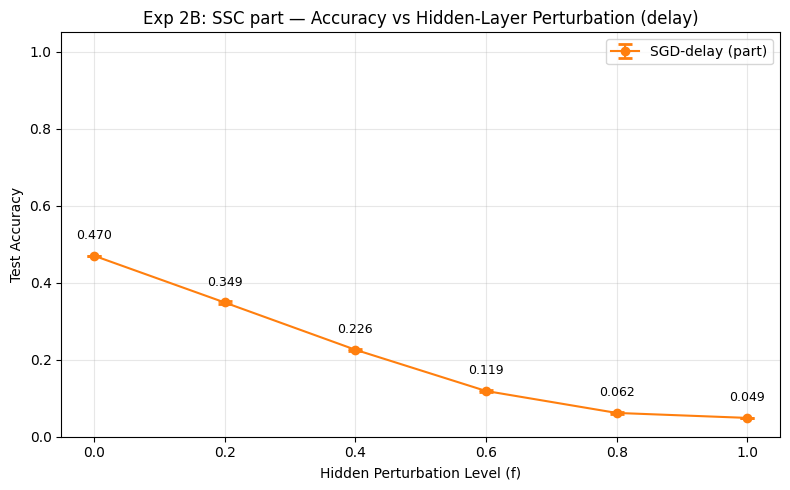

Figure saved to log/ssc_part_delay_hidden_perturbation.png


In [13]:
plot_hidden_perturbation_curve(sweep_results)

## 14. Save Results

Save the sweep results and training log to JSON for later comparison
across dataset variants and delay/no-delay modes.

In [ ]:
# The run cell above already persists each variation's results via
# run_variation_sweep; this cell re-saves every in-memory variation so the
# "Save Results" step can be run standalone.
os.makedirs("log", exist_ok=True)

for (ds_key, ud), run in all_variation_runs.items():
    prefix = run["model_prefix"]
    results_serialisable = {
        str(f_val): {
            "mean":   float(data["mean"]),
            "std":    float(data["std"]),
            "values": [float(v) for v in data["values"]],
        }
        for f_val, data in run["results"].items()
    }
    results_path = f"log/{prefix}_hidden_perturbation_results.json"
    with open(results_path, "w") as fp:
        json.dump(results_serialisable, fp, indent=2)
    print(f"Results saved to {results_path}")

## 15. Model Analysis

Print delay statistics and weight statistics for inspection.

In [15]:
print(
    f"=== Learned Parameter Analysis "
    f"(SSC {DATASET_KEY}, {DELAY_TAG}) ==="
)

# Delay statistics
delays = net.get_delays()
if delays:
    for delay_name, delay_values in delays.items():
        if len(delay_values) > 0:
            print(
                f"Learned {delay_name}: "
                f"mean={np.mean(delay_values):.2f}, "
                f"std={np.std(delay_values):.2f}, "
                f"min={np.min(delay_values):.2f}, "
                f"max={np.max(delay_values):.2f}"
            )
else:
    print("No delays (SGD mode)")

# Weight statistics per layer
for name, param in net.named_parameters():
    if "weight" in name:
        w = param.data
        print(
            f"{name}: mean={w.mean().item():.4f}, "
            f"std={w.std().item():.4f}, "
            f"shape={list(w.shape)}"
        )

=== Learned Parameter Analysis (SSC part, delay) ===
Learned delay1: mean=47.10, std=25.07, min=0.00, max=66.00
Learned delay2: mean=64.47, std=6.56, min=0.00, max=66.00
fc1.weight_g: mean=24.7848, std=35.8471, shape=[128, 1, 1, 1, 1]
fc1.weight_v: mean=1.6202, std=19.4739, shape=[128, 285, 1, 1, 1]
fc2.weight_g: mean=112.6163, std=93.6151, shape=[128, 1, 1, 1, 1]
fc2.weight_v: mean=-0.2212, std=15.1558, shape=[128, 128, 1, 1, 1]
fc3.weight_g: mean=170.9372, std=82.1553, shape=[35, 1, 1, 1, 1]
fc3.weight_v: mean=-6.0918, std=27.9792, shape=[35, 128, 1, 1, 1]
